In [1]:
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

sns.set(style="whitegrid")

# Paths

BASE_DIR = Path().resolve().parent  
ML_DIR = BASE_DIR / "ML_pipeline"
print("BASE_DIR:", BASE_DIR)
print("ML_DIR:", ML_DIR)

# Match interp_type to how you trained the model
interp_type = "kriging"  # "kriging" or "IDW"

if interp_type == "IDW":
    interp_type_folder = "withIDW_v3"
elif interp_type == "kriging":
    interp_type_folder = "withKriging_v3"
else:
    raise ValueError(f"Unknown interp_type: {interp_type}")

MODEL_OUT_DIR = ML_DIR / "model_artifacts" / interp_type_folder
GRAPHICS_DIR = MODEL_OUT_DIR / "graphics_evaluation"
GRAPHICS_DIR.mkdir(exist_ok=True, parents=True)

print("MODEL_OUT_DIR:", MODEL_OUT_DIR)
print("GRAPHICS_DIR:", GRAPHICS_DIR)

BASE_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype
ML_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\ML_pipeline
MODEL_OUT_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\ML_pipeline\model_artifacts\withKriging_v3
GRAPHICS_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\ML_pipeline\model_artifacts\withKriging_v3\graphics_evaluation


In [ ]:
# Load saved data

X_test_all = pd.read_parquet(MODEL_OUT_DIR / "X_test_all.parquet")
y_test_df = pd.read_parquet(MODEL_OUT_DIR / "y_test.parquet")
df_test_predictions = pd.read_parquet(MODEL_OUT_DIR / "test_predictions.parquet")

with open(MODEL_OUT_DIR / "model_metadata.json", "r") as f:
    metadata = json.load(f)

print("Loaded:")
print("  X_test_all:", X_test_all.shape)
print("  y_test_df:", y_test_df.shape)
print("  df_test_predictions:", df_test_predictions.shape)

threshold = metadata["confidence_threshold"]
print("Abstention threshold:", threshold)

Loaded:
  X_test_all: (3919579, 6)
  y_test_df: (3919579, 2)
  df_test: (3919579, 11)
Abstention threshold: 0.635


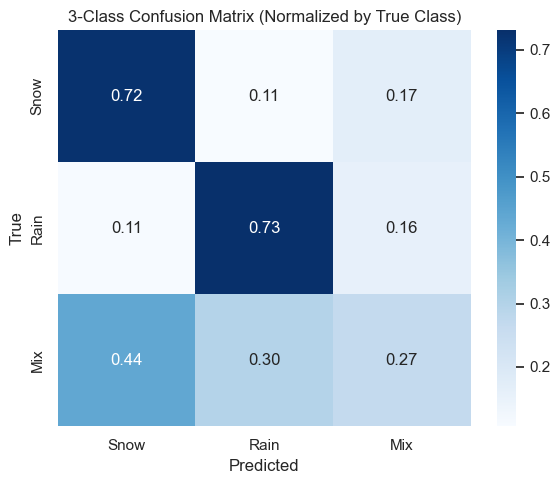

In [ ]:
assert len(df_test_predictions) == len(X_test_all)
assert len(df_test_predictions) == len(y_test_df)

# ==========================================
# 3-CLASS CONFUSION MATRIX
# ==========================================

y_true = df_test_predictions["phase_full"].values
y_pred = df_test_predictions["pred_phase_abst"].values

labels = [0, 1, 2]
class_names = ["Snow", "Rain", "Mix"]

cm = confusion_matrix(y_true, y_pred, labels=labels)

cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("3-Class Confusion Matrix (Normalized by True Class)")
plt.tight_layout()
plt.savefig(GRAPHICS_DIR / "confusion_matrix_3class.png", dpi=300)
plt.show()

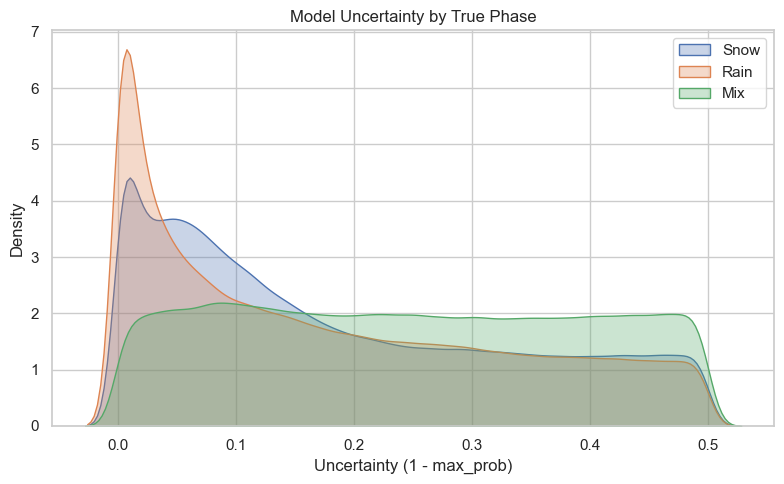

In [ ]:

# ==========================================
# UNCERTAINTY DISTRIBUTION BY TRUE CLASS
# ==========================================

df_test_predictions["uncertainty"] = 1 - df_test_predictions["max_prob"]

plt.figure(figsize=(8,5))

for cls, label in zip([0,1,2], ["Snow","Rain","Mix"]):
    subset = df_test_predictions[df_test_predictions["phase_full"] == cls]
    sns.kdeplot(
        subset["uncertainty"],
        label=label,
        fill=True,
        alpha=0.3
    )

plt.xlabel("Uncertainty (1 - max_prob)")
plt.ylabel("Density")
plt.title("Model Uncertainty by True Phase")
plt.legend()
plt.tight_layout()
plt.savefig(GRAPHICS_DIR / "uncertainty_by_true_class.png", dpi=300)
plt.show()

C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_16336\458311697.py:22: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_16336\458311697.py:23: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(GRAPHICS_DIR / "probability_vs_wetbulb.png", dpi=300)
c:\Users\EmmaGolub\Desktop\MRoS_local\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


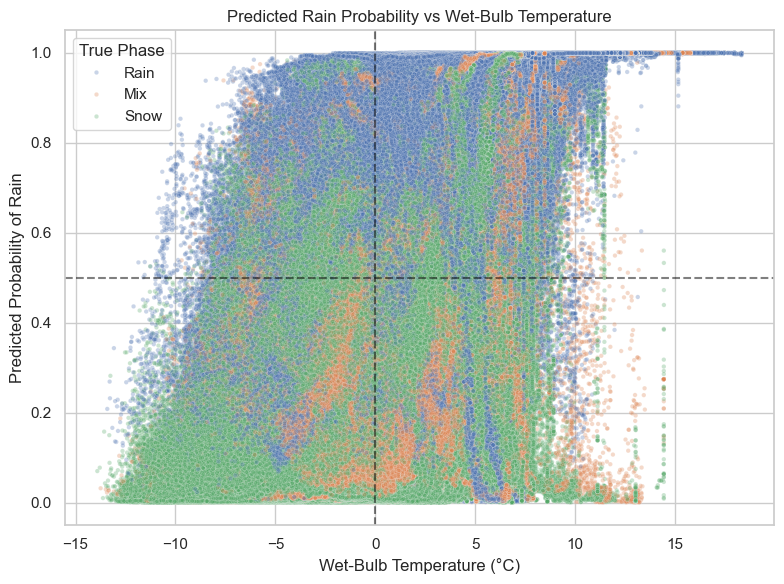

In [6]:
# ==========================================
# P_RAIN vs WET-BULB TEMPERATURE
# ==========================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_test_all["temp_wet"],
    y=df_test_predictions["p_rain"],
    hue=df_test_predictions["phase_full"].map({0:"Snow",1:"Rain",2:"Mix"}),
    alpha=0.3,
    s=10
)

plt.axhline(0.5, linestyle="--", color="black", alpha=0.5)
plt.axvline(0.0, linestyle="--", color="black", alpha=0.5)

plt.xlabel("Wet-Bulb Temperature (°C)")
plt.ylabel("Predicted Probability of Rain")
plt.title("Predicted Rain Probability vs Wet-Bulb Temperature")
plt.legend(title="True Phase")
plt.tight_layout()
plt.savefig(GRAPHICS_DIR / "probability_vs_wetbulb.png", dpi=300)
plt.show()